In [1]:
import numpy as np
import pandas as pd
import json
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from pathlib import Path
from tqdm.notebook import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DATASET_ROOT = Path("../../src/dataset")
POSES_ROOT   = DATASET_ROOT / "poses"
METADATA_DIR = DATASET_ROOT / "metadata"

SIGNS_TARGET = [
    "SOUFFRIR", "AIDER",    "FORT",     "MALADE",   "COEUR",
    "TETE",     "MORT",     "PLEURER",      "NON",   "FROID",
    "MANGER",    "OUI",   "TOMBER", "ACCIDENT", "MARCHER",
    "ENCEINTE", "DORMIR",  "BOIRE",     "CHAUD",  "MEDECIN"
]
SIGN_TO_IDX = {s: i for i, s in enumerate(SIGNS_TARGET)}
IDX_TO_SIGN = {i: s for i, s in enumerate(SIGNS_TARGET)}
NUM_CLASSES  = len(SIGNS_TARGET)
TARGET_T     = 32   # fixed temporal length

print(f"Classes: {NUM_CLASSES}, Target T: {TARGET_T}")

Using device: cuda
Classes: 20, Target T: 32


In [2]:
instances = pd.read_csv(DATASET_ROOT / "instances.csv")
face_files = list((POSES_ROOT / "face").glob("*.npy"))
available  = {f.stem for f in face_files}

df = instances[instances["id"].isin(available)].copy()
df["label"] = df["sign"].map(SIGN_TO_IDX)
df = df[df["label"].notna()].copy()
df["label"] = df["label"].astype(int)

# Remove T=0 instances
lengths = {f.stem: np.load(f).shape[0] for f in face_files if f.stem in set(df["id"])}
df["T"] = df["id"].map(lengths)
df = df[df["T"] > 0].reset_index(drop=True)

# Load splits
with open(METADATA_DIR / "splits" / "train.json") as f:
    train_ids = set(json.load(f))
with open(METADATA_DIR / "splits" / "test.json") as f:
    test_ids = set(json.load(f))

df_train = df[df["id"].isin(train_ids)].reset_index(drop=True)
df_test  = df[df["id"].isin(test_ids)].reset_index(drop=True)

print(f"Train: {len(df_train)} | Test: {len(df_test)}")
print("\nClass distribution (train):")
print(df_train["sign"].value_counts().to_string())

Train: 2856 | Test: 2225

Class distribution (train):
sign
OUI         1291
NON          599
FORT         279
AIDER        116
MANGER       115
CHAUD         55
TOMBER        51
DORMIR        51
BOIRE         49
MARCHER       40
PLEURER       30
FROID         25
ENCEINTE      25
MORT          24
TETE          22
SOUFFRIR      21
COEUR         21
MALADE        17
ACCIDENT      16
MEDECIN        9


In [3]:
def resample_sequence(arr: np.ndarray, target_T: int) -> np.ndarray:
    """Resample (T, K, 3) array to target_T frames via linear interpolation."""
    T = arr.shape[0]
    if T == target_T:
        return arr
    idx = np.linspace(0, T - 1, target_T)
    lo  = np.floor(idx).astype(int).clip(0, T - 1)
    hi  = np.ceil(idx).astype(int).clip(0, T - 1)
    a   = (idx - lo)[:, None, None]
    return ((1 - a) * arr[lo] + a * arr[hi]).astype(np.float32)


def load_coords(instance_id: str, target_T: int = TARGET_T) -> np.ndarray:
    """
    Load body + left_hand + right_hand coordinates for one instance.

    Returns float32 array of shape (225, T):
      - 225 = (33 body + 21 left_hand + 21 right_hand) * 3 coords
      - T   = target_T frames
    Channel-first format for Conv1d input.
    """
    body  = np.load(POSES_ROOT / "pose"       / f"{instance_id}.npy").astype(np.float32)
    lhand = np.load(POSES_ROOT / "left_hand"  / f"{instance_id}.npy").astype(np.float32)
    rhand = np.load(POSES_ROOT / "right_hand" / f"{instance_id}.npy").astype(np.float32)

    body  = resample_sequence(body,  target_T)   # (T, 33, 3)
    lhand = resample_sequence(lhand, target_T)   # (T, 21, 3)
    rhand = resample_sequence(rhand, target_T)   # (T, 21, 3)

    # Flatten keypoints: (T, K, 3) -> (T, K*3) then transpose to (K*3, T)
    body_flat  = body.reshape(target_T, -1)    # (T, 99)
    lhand_flat = lhand.reshape(target_T, -1)   # (T, 63)
    rhand_flat = rhand.reshape(target_T, -1)   # (T, 63)

    coords = np.concatenate([body_flat, lhand_flat, rhand_flat], axis=1)  # (T, 225)
    return coords.T  # (225, T) channel-first for Conv1d


# Sanity check
sample_id = df_train["id"].iloc[0]
x = load_coords(sample_id)
assert x.shape == (225, TARGET_T), f"Expected (225, {TARGET_T}), got {x.shape}"
print(f"load_coords OK: shape={x.shape}, range=[{x.min():.3f}, {x.max():.3f}]")

load_coords OK: shape=(225, 32), range=[-1.016, 1.717]


In [4]:
def augment_horizontal_flip(coords: np.ndarray) -> np.ndarray:
    """
    Flip x-coordinate and swap left/right hand channels.
    coords shape: (225, T) = (99 body + 63 lhand + 63 rhand, T)
    x values are at indices 0, 3, 6, ... within each keypoint group (stride 3).
    """
    c = coords.copy()
    # Flip x (index 0, 3, 6, ...) for all keypoints: negate and shift
    # Coords are in [0,1], so flip x = 1 - x
    for start in range(225):
        if start % 3 == 0:  # x coordinate
            c[start] = 1.0 - c[start]
    # Swap left hand (99:162) and right hand (162:225)
    tmp = c[99:162].copy()
    c[99:162]  = c[162:225]
    c[162:225] = tmp
    return c


def augment_temporal_flip(coords: np.ndarray) -> np.ndarray:
    """Reverse temporal axis. coords shape: (225, T)"""
    return coords[:, ::-1].copy()


def augment_jitter(coords: np.ndarray, std: float = 0.01) -> np.ndarray:
    """Add Gaussian noise to coordinates (not confidence values)."""
    c = coords.copy()
    noise = np.random.randn(*c.shape).astype(np.float32) * std
    # Zero out noise on confidence channels (index 2, 5, 8, ...)
    for i in range(225):
        if i % 3 == 2:
            noise[i] = 0.0
    return np.clip(c + noise, 0.0, 1.0)


def augment_time_warp(coords: np.ndarray, sigma: float = 0.2) -> np.ndarray:
    """
    Randomly speed up or slow down different parts of the sequence.
    sigma: std of the warp factor (centered on 1.0).
    """
    T = coords.shape[1]
    # Sample a smooth warp along time axis
    warp = np.cumsum(np.abs(np.random.randn(T) * sigma + 1.0))
    warp = (warp - warp[0]) / (warp[-1] - warp[0]) * (T - 1)
    lo   = np.floor(warp).astype(int).clip(0, T - 1)
    hi   = np.ceil(warp).astype(int).clip(0, T - 1)
    a    = (warp - lo)[None, :]  # (1, T)
    return ((1 - a) * coords[:, lo] + a * coords[:, hi]).astype(np.float32)


print("Augmentation functions defined.")

Augmentation functions defined.


In [5]:
class CoordDataset(Dataset):
    """
    Loads raw skeleton coordinates on-the-fly from disk with optional augmentation.

    Returns tensors of shape (225, T) and integer labels.
    """

    def __init__(self, df: pd.DataFrame, augment: bool = False, target_T: int = TARGET_T):
        self.df       = df.reset_index(drop=True)
        self.augment  = augment
        self.target_T = target_T

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        coords = load_coords(row["id"], self.target_T)  # (225, T)

        if self.augment:
            if np.random.rand() < 0.5:
                coords = augment_horizontal_flip(coords)
            if np.random.rand() < 0.5:
                coords = augment_temporal_flip(coords)
            if np.random.rand() < 0.5:
                coords = augment_jitter(coords)
            if np.random.rand() < 0.5:
                coords = augment_time_warp(coords)

        return torch.from_numpy(coords.copy()), torch.tensor(row["label"], dtype=torch.long)


train_dataset = CoordDataset(df_train, augment=True)
test_dataset  = CoordDataset(df_test,  augment=False)

# np.bincount with minlength=NUM_CLASSES ensures all 20 classes are represented
# even if some are absent from the train set (e.g. OUI has 0 train instances)
class_counts   = np.bincount(df_train["label"].values, minlength=NUM_CLASSES).astype(np.float32)
class_weights  = 1.0 / np.maximum(class_counts, 1.0)
sample_weights = class_weights[df_train["label"].values]

sampler = WeightedRandomSampler(
    weights     = torch.tensor(sample_weights, dtype=torch.float32),
    num_samples = len(df_train),
    replacement = True,
)

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False,    num_workers=0)

xb, yb = next(iter(train_loader))
print(f"Batch: X={xb.shape}, y={yb.shape}, dtype={xb.dtype}")

Batch: X=torch.Size([16, 225, 32]), y=torch.Size([16]), dtype=torch.float32


In [6]:
class TemporalBlock(nn.Module):
    """
    One residual TCN block:
      - Two dilated causal Conv1d layers with same padding
      - BatchNorm + ReLU + Dropout after each conv
      - Residual connection (with 1x1 conv if channel dims differ)
    """

    def __init__(self, in_channels: int, out_channels: int,
                 kernel_size: int = 3, dilation: int = 1,
                 dropout: float = 0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2  # same padding

        self.conv1 = nn.Conv1d(in_channels,  out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn1   = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn2   = nn.BatchNorm1d(out_channels)

        self.relu    = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

        self.downsample = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels else None
        )

    def forward(self, x):
        residual = x if self.downsample is None else self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.dropout(out)
        return self.relu(out + residual)


class TCN(nn.Module):
    """
    Temporal Convolutional Network for skeleton-based sign recognition.

    Input:  (batch, 225, T=32)   — raw coordinate features, channel-first
    Output: (batch, num_classes)

    Architecture:
      Linear projection 225 -> 128
      4 TemporalBlocks with exponentially growing dilation (1, 2, 4, 8)
      Global average pooling over time
      Dropout + Linear classifier
    """

    def __init__(self, in_channels: int = 225, num_classes: int = 20,
                 hidden: int = 128, dropout: float = 0.3):
        super().__init__()

        self.input_proj = nn.Conv1d(in_channels, hidden, kernel_size=1)

        self.blocks = nn.Sequential(
            TemporalBlock(hidden, hidden, kernel_size=3, dilation=1,  dropout=dropout),
            TemporalBlock(hidden, hidden, kernel_size=3, dilation=2,  dropout=dropout),
            TemporalBlock(hidden, hidden, kernel_size=3, dilation=4,  dropout=dropout),
            TemporalBlock(hidden, hidden, kernel_size=3, dilation=8,  dropout=dropout),
        )

        self.pool      = nn.AdaptiveAvgPool1d(1)
        self.dropout   = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_classes)

    def forward(self, x):
        # x: (B, 225, T)
        x = self.input_proj(x)    # (B, 128, T)
        x = self.blocks(x)        # (B, 128, T)
        x = self.pool(x).squeeze(-1)  # (B, 128)
        x = self.dropout(x)
        return self.classifier(x) # (B, num_classes)


# Verify
model = TCN(in_channels=225, num_classes=NUM_CLASSES, hidden=128, dropout=0.3).to(DEVICE)
dummy = torch.randn(4, 225, TARGET_T).to(DEVICE)
out   = model(dummy)
assert out.shape == (4, NUM_CLASSES), f"Expected (4,{NUM_CLASSES}), got {out.shape}"

total_params = sum(p.numel() for p in model.parameters())
print(f"TCN output shape: {out.shape}  [OK]")
print(f"Total parameters: {total_params:,}  (vs I3D ~12M)")

TCN output shape: torch.Size([4, 20])  [OK]
Total parameters: 427,796  (vs I3D ~12M)


In [7]:
os.makedirs("../../src/models", exist_ok=True)

# Inverse-frequency class weights — bincount guarantees all 20 classes present
counts     = np.bincount(df_train["label"].values, minlength=NUM_CLASSES).astype(np.float32)
ce_weights = torch.tensor(1.0 / np.maximum(counts, 1.0), dtype=torch.float32).to(DEVICE)
ce_weights /= ce_weights.sum()

criterion = nn.CrossEntropyLoss(weight=ce_weights)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-5)

print("Loss, optimizer, scheduler defined.")
print(f"  LR: {optimizer.param_groups[0]['lr']:.1e}")
print(f"  Weight decay: {optimizer.param_groups[0]['weight_decay']:.1e}")

Loss, optimizer, scheduler defined.
  LR: 3.0e-04
  Weight decay: 1.0e-03


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds       = logits.argmax(1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / total
    accuracy = correct / total
    f1       = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, accuracy, f1, np.array(all_preds), np.array(all_labels)


print("train_one_epoch and evaluate defined.")

train_one_epoch and evaluate defined.


In [ ]:
NUM_EPOCHS        = 80
PATIENCE          = 15
best_val_acc      = 0.0
epochs_no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
            f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
            f"val loss={val_loss:.4f} acc={val_acc:.3f} f1={val_f1:.3f} | "
            f"lr={lr:.1e}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "../../src/models/best_tcn.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 001/80 | train loss=2.2485 acc=0.208 | val loss=5.4945 acc=0.021 f1=0.026 | lr=3.0e-04
Epoch 010/80 | train loss=0.7669 acc=0.571 | val loss=5.5703 acc=0.045 f1=0.121 | lr=2.9e-04
Epoch 020/80 | train loss=0.4487 acc=0.675 | val loss=4.1022 acc=0.063 f1=0.105 | lr=2.6e-04
Epoch 030/80 | train loss=0.2914 acc=0.760 | val loss=3.9946 acc=0.112 f1=0.158 | lr=2.1e-04
Epoch 040/80 | train loss=0.2125 acc=0.798 | val loss=3.5894 acc=0.145 f1=0.175 | lr=1.5e-04
Epoch 050/80 | train loss=0.1468 acc=0.834 | val loss=2.7805 acc=0.283 f1=0.259 | lr=1.0e-04
Epoch 060/80 | train loss=0.1261 acc=0.843 | val loss=3.0161 acc=0.301 f1=0.270 | lr=5.2e-05
Epoch 070/80 | train loss=0.0951 acc=0.864 | val loss=2.7975 acc=0.317 f1=0.287 | lr=2.1e-05
Epoch 080/80 | train loss=0.0841 acc=0.875 | val loss=2.7207 acc=0.362 f1=0.302 | lr=1.0e-05

Best validation accuracy: 0.3829


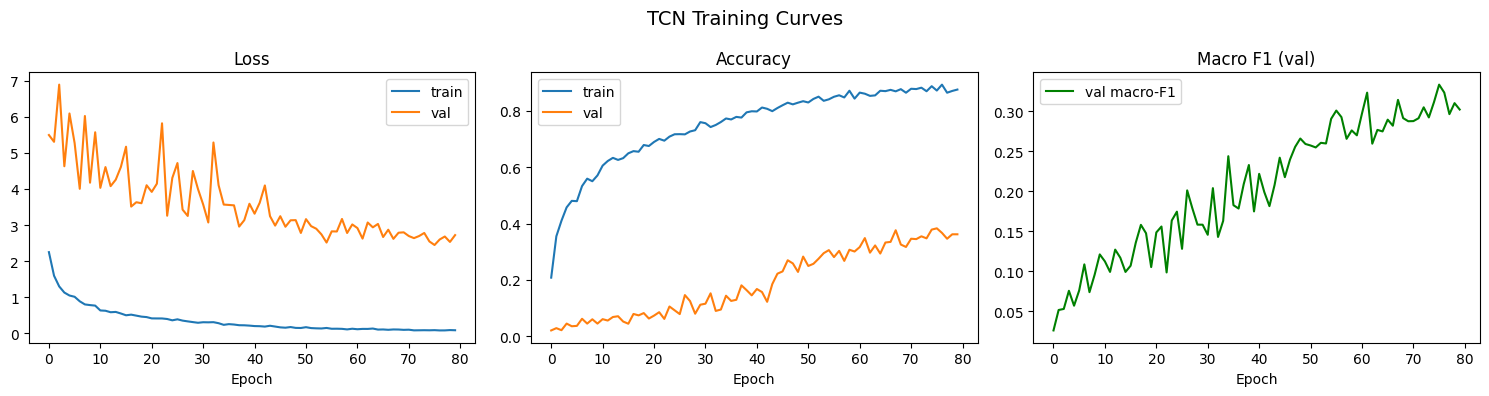

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history["val_f1"], label="val macro-F1", color="green")
axes[2].set_title("Macro F1 (val)")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("TCN Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Load best checkpoint
model.load_state_dict(torch.load("../../src/models/best_tcn.pth", map_location=DEVICE))

_, test_acc, test_f1, preds, labels = evaluate(model, test_loader, criterion, DEVICE)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Macro-F1 : {test_f1:.4f}")
print()
print(classification_report(labels, preds, target_names=SIGNS_TARGET, zero_division=0))

Test Accuracy : 0.3829
Test Macro-F1 : 0.3330

              precision    recall  f1-score   support

    SOUFFRIR       0.12      0.71      0.21        17
       AIDER       0.82      0.75      0.78        53
        FORT       0.69      0.50      0.58       205
      MALADE       0.27      0.89      0.41         9
       COEUR       0.35      0.67      0.46         9
        TETE       0.14      0.14      0.14        14
        MORT       0.17      0.67      0.27        12
     PLEURER       0.21      0.48      0.29        21
         NON       0.53      0.57      0.55       583
       FROID       0.05      0.14      0.08        22
      MANGER       0.43      0.62      0.50        92
         OUI       0.91      0.18      0.29      1013
      TOMBER       0.12      0.39      0.18        18
    ACCIDENT       0.00      0.00      0.00         4
     MARCHER       0.21      0.55      0.30        38
    ENCEINTE       0.28      0.79      0.42        14
      DORMIR       0.29      0.84 

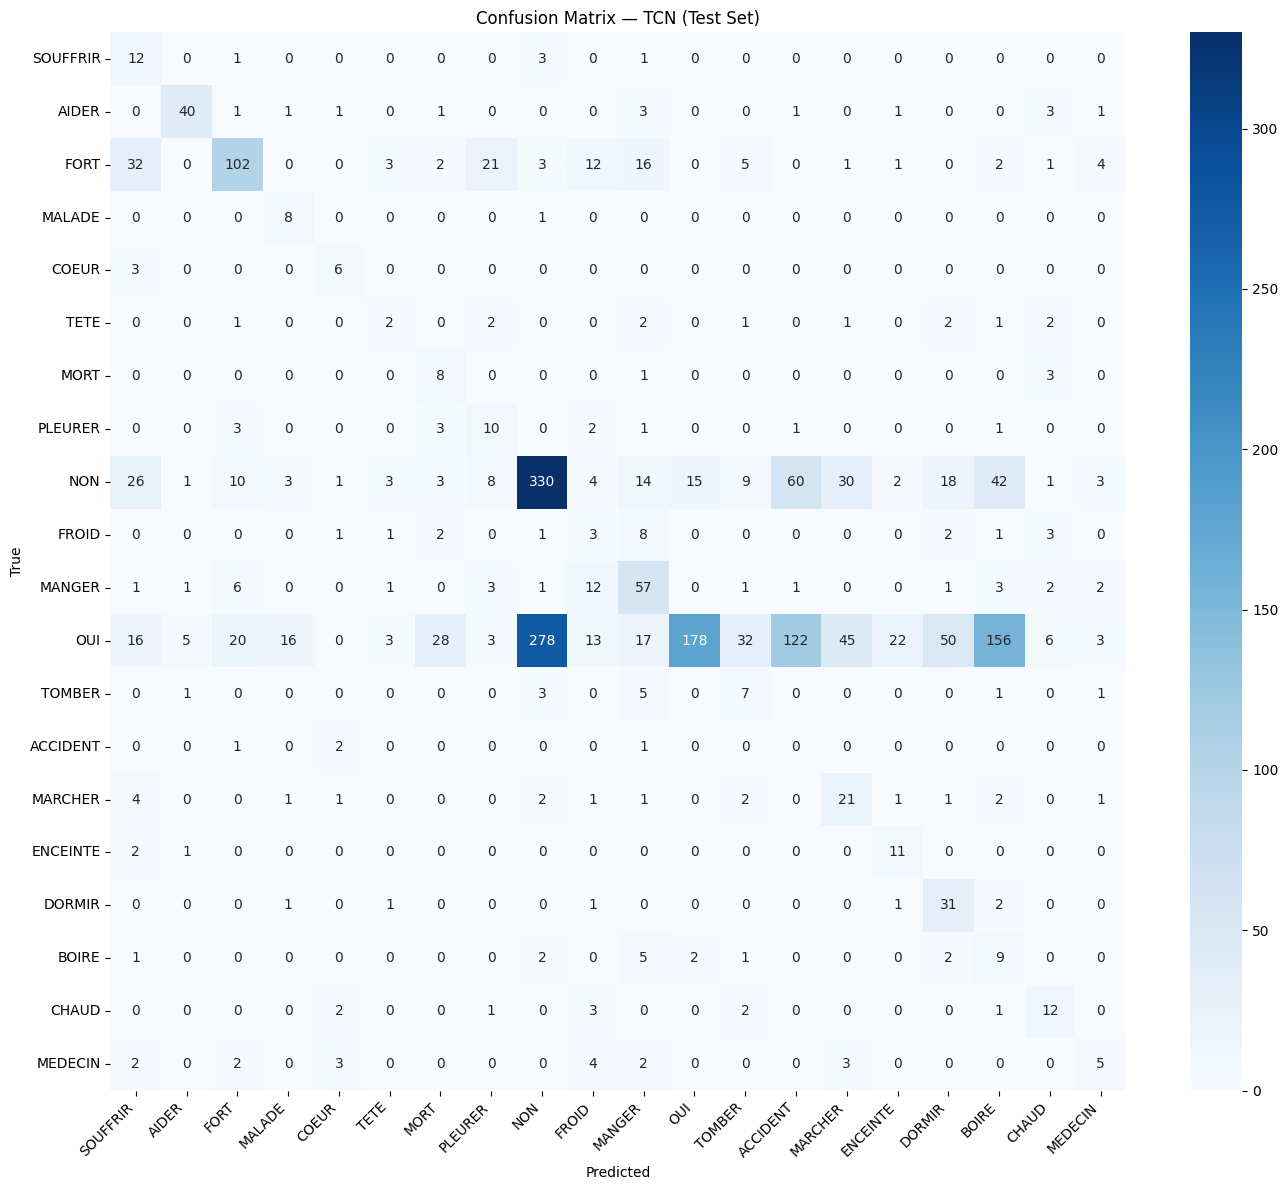

In [12]:
cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=SIGNS_TARGET,
    yticklabels=SIGNS_TARGET,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — TCN (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
def save_tcn(model: nn.Module, path: str, metadata: dict = None):
    """Save TCN weights and optional metadata."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {"state_dict": model.state_dict()}
    if metadata:
        payload["metadata"] = metadata
    torch.save(payload, path)
    print(f"Model saved to {path}")


def predict_sign_tcn(instance_id: str, model: nn.Module, device) -> tuple:
    """
    Predict the sign for a single instance from its pose files.
    Returns: (predicted_sign_name, confidence_score)
    """
    model.eval()
    coords = load_coords(instance_id, TARGET_T)  # (225, T)
    x = torch.from_numpy(coords).unsqueeze(0).to(device)  # (1, 225, T)
    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)
        idx    = probs.argmax(1).item()
        conf   = probs[0, idx].item()
    return IDX_TO_SIGN[idx], conf


# Save with metadata
save_tcn(model, "../../src/models/tcn_medisign_final.pth", metadata={
    "test_accuracy": round(float(test_acc), 4),
    "test_macro_f1": round(float(test_f1), 4),
    "num_classes":   NUM_CLASSES,
    "signs":         SIGNS_TARGET,
    "input_shape":   [225, TARGET_T],
    "architecture":  "TCN (4 TemporalBlocks, hidden=128)",
})

# Inference examples
print("\nInference examples:")
for sign in ["SOUFFRIR", "AIDER", "FORT", "COEUR", "TETE"]:
    row  = df[df["sign"] == sign].iloc[0]
    pred, conf = predict_sign_tcn(row["id"], model, DEVICE)
    status = "OK" if pred == sign else "X"
    print(f"  [{status}] True: {sign:<12} Pred: {pred:<12} Conf: {conf:.3f}")

Model saved to ../../src/models/tcn_medisign_final.pth

Inference examples:
  [OK] True: SOUFFRIR     Pred: SOUFFRIR     Conf: 0.988
  [OK] True: AIDER        Pred: AIDER        Conf: 0.997
  [OK] True: FORT         Pred: FORT         Conf: 0.456
  [OK] True: COEUR        Pred: COEUR        Conf: 0.879
  [X] True: TETE         Pred: BOIRE        Conf: 0.990
